In [1]:
import pandas as pd
import numpy as np
import os
from matplotlib.pyplot import *
import matplotlib.font_manager as fm

rcParams['mathtext.rm'] = "Arial"
rcParams['font.family'] = 'Arial'
for f in fm.findSystemFonts(fontpaths=None, fontext='ttf'):
    if 'arial' in f.lower():
        print(f)

C:\Windows\Fonts\arial.ttf
C:\Windows\Fonts\ariali.ttf
C:\Windows\Fonts\arialbi.ttf
C:\Windows\Fonts\arialbd.ttf


In [2]:
from model_training import load_data
path1 = "training_data/for_model1.csv"
path2 = "training_data/for_model2.csv"
X1, Y1 = load_data(path1)
X2, Y2 = load_data(path2)

In [3]:
from sklearn.manifold import TSNE
from matplotlib.pyplot import *
from matplotlib import pyplot as plt 

rcParams['mathtext.rm'] = "Arial"
rcParams['font.family'] = 'Arial'

# Run t-SNE
def plot_tsne(X, Y):
    tsne = TSNE(n_components=2, random_state=42)
    X_tsne = tsne.fit_transform(X)

    # Plot
    plt.figure(figsize=(8, 8))
    label = True
    idx = (Y == label)
    plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1], label=str(label), alpha=0.7, s=40, c = "red")

    label = False
    idx = (Y == label)
    plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1], label=str(label), alpha=0.7, s=40, c = "blue")

    plt.xticks(fontsize = 12)
    plt.yticks(fontsize = 12)
    plt.legend(fontsize = 12, loc='upper left')

    plt.xlabel("t-SNE 1", fontsize=18)
    plt.ylabel("t-SNE 2", fontsize=18)

    plt.tight_layout()
    plt.show()
    return plt


In [4]:
def plot_combined_tsne(X1, Y1, X2, Y2):
    # 将两个数据集合并
    X_combined = np.vstack([X1, X2])
    
    
    # 创建新的标签编码:
    # 0: 无晶体 (来自第一阶段)
    # 1: Gd104晶体 (来自第二阶段)
    # 2: Gd42晶体 (来自第二阶段)
    
    Y_combined = np.zeros(len(X1) + len(X2), dtype=int)
    Y_combined[:len(X1)] = Y1
    stage2_start = len(X1)
    for i in range(len(X2)):
        if Y2[i] == 0:  # Gd104晶体
            Y_combined[stage2_start + i] = 1
        else:  # Gd42晶体
            Y_combined[stage2_start + i] = 2
    
    # 应用t-SNE
    tsne = TSNE(n_components=2, random_state=42)
    X_tsne = tsne.fit_transform(X_combined)
    
    # 绘图
    plt.figure(figsize=(10, 8))
    
    # 定义颜色和标签
    colors = ['blue', 'red', 'green']
    labels = ['无晶体', 'Gd104晶体', 'Gd42晶体']
    
    for i, (color, label) in enumerate(zip(colors, labels)):
        idx = (Y_combined == i)
        plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1], 
                   label=label, alpha=0.7, s=40, c=color)
    
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(fontsize=12, loc='upper left')
    plt.xlabel("t-SNE 1", fontsize=18)
    plt.ylabel("t-SNE 2", fontsize=18)
    plt.title("两阶段晶体分类 t-SNE 可视化", fontsize=16)
    plt.tight_layout()
    plt.show()
    return plt


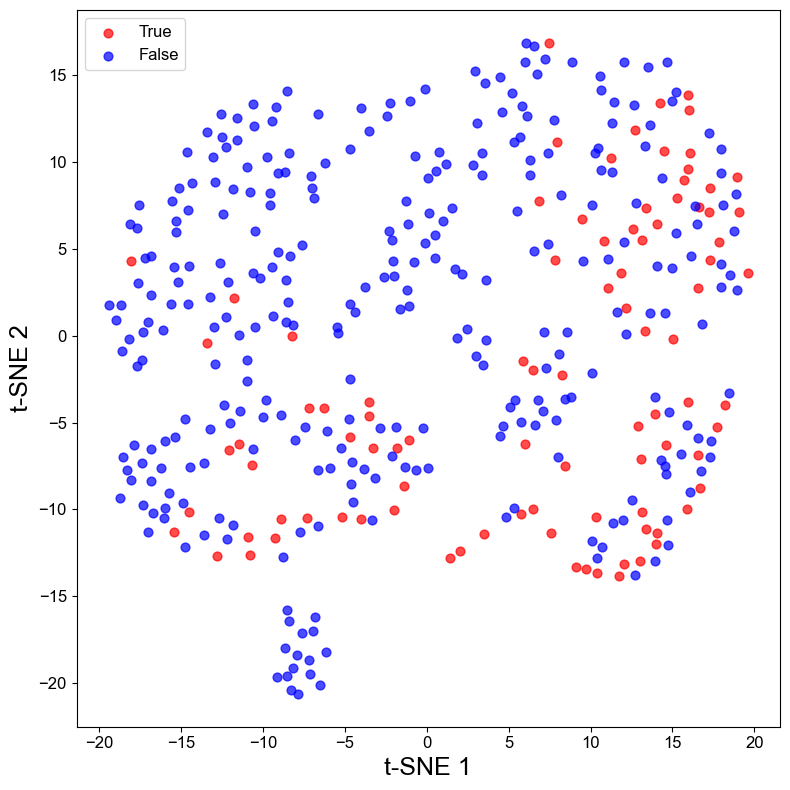

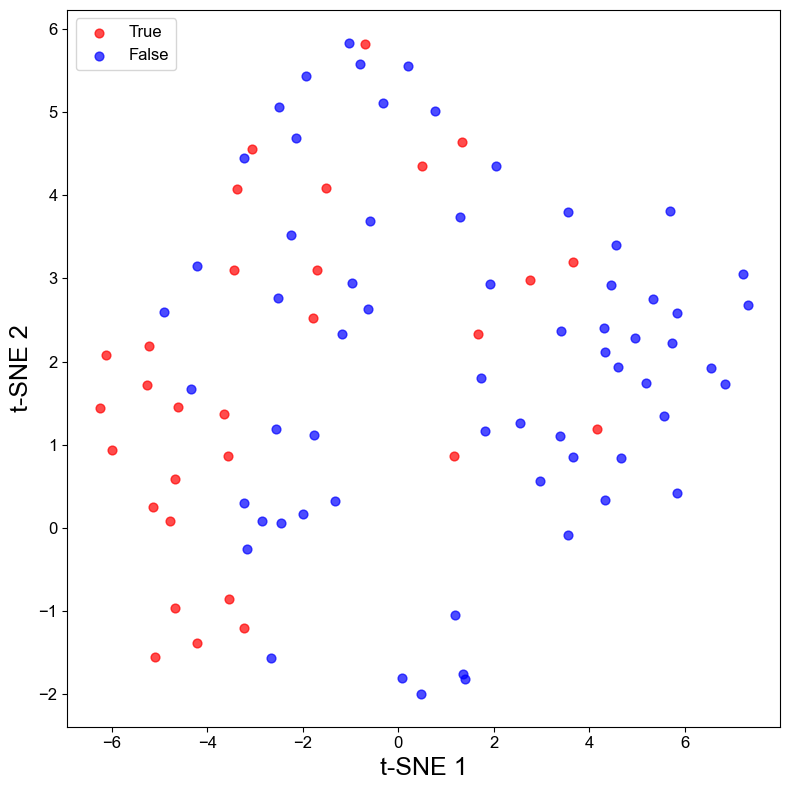

<module 'matplotlib.pyplot' from 'd:\\workspace\\Phase_Diagram\\.venv\\Lib\\site-packages\\matplotlib\\pyplot.py'>

In [5]:
plot_tsne(X1, Y1)
plot_tsne(X2, Y2)

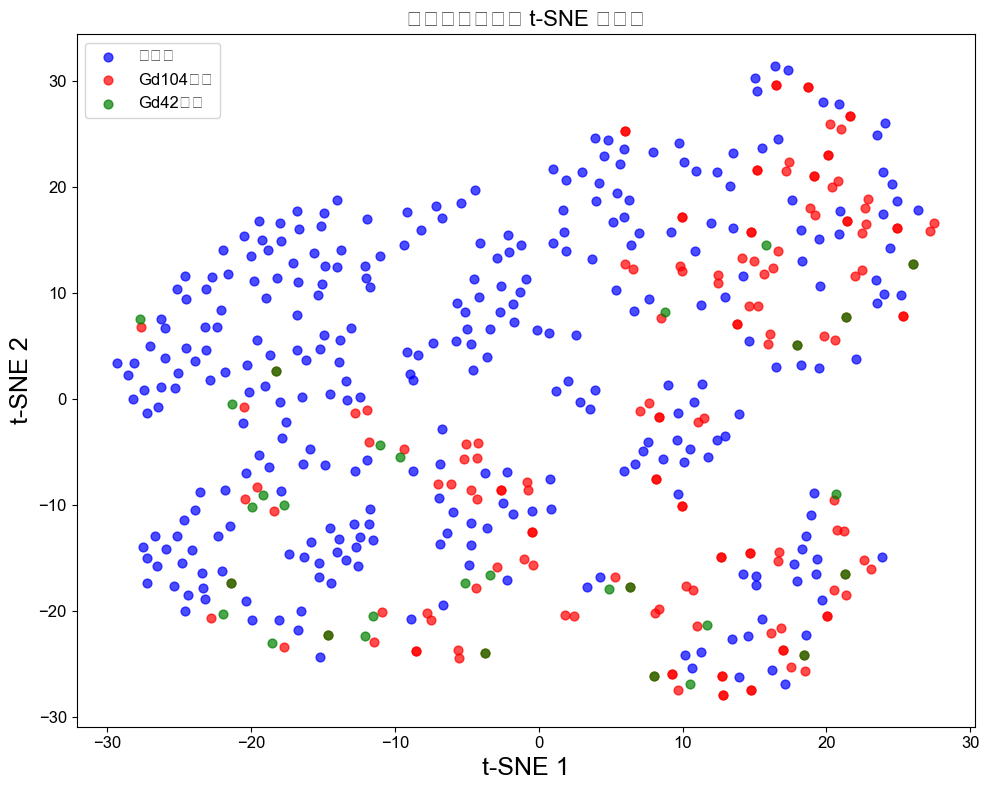

<module 'matplotlib.pyplot' from 'd:\\workspace\\Phase_Diagram\\.venv\\Lib\\site-packages\\matplotlib\\pyplot.py'>

In [6]:
plot_combined_tsne(X1, Y1, X2, Y2)